# **Load Data**

In [ ]:
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
playerData = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/nbaPlayerData.csv')

display(playerData.head())

print(playerData.columns)

,Year,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards,Player-additional
0,1980,George Gervin,27,SAS,SG,78,NaN,37.6,13.1,24.9,...,3.2,5.2,2.6,1.4,1.0,3.3,2.7,33.1,MVP-3ASNBA1,gervige01
1,1980,World B. Free,26,SDC,SG,68,NaN,38.0,10.8,22.9,...,1.6,3.5,4.2,1.2,0.5,3.4,2.9,30.2,AS,freewo01
2,1980,Adrian Dantley,24,UTA,SF,68,NaN,39.3,10.7,18.6,...,4.9,7.6,2.8,1.4,0.2,3.4,3.1,28.0,AS,dantlad01
3,1980,Julius Erving,29,PHI,SF,78,78.0,36.1,10.7,20.7,...,4.6,7.4,4.6,2.2,1.8,3.6,2.7,26.9,MVP-2ASNBA1,ervinju01
4,1980,Moses Malone,24,HOU,C,82,82.0,38.3,9.5,18.9,...,7.5,14.5,1.8,1.0,1.3,3.7,2.6,25.8,MVP-9ASNBA2,malonmo01


Index(['Year', 'Player', 'Age', 'Team', 'Pos', 'G', 'GS', 'MP', 'FG', 'FGA',
       'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA',
       'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS',
       'Awards', 'Player-additional'],
      dtype='object')


In [ ]:
rosters = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/nba_rosters_1980_present.csv')

display(rosters.head())

print(rosters.columns)

,Year,Team,Player
0,1980,Los Angeles Lakers,Kareem Abdul-Jabbar
1,1980,Los Angeles Lakers,Ron Boone
2,1980,Los Angeles Lakers,Marty Byrnes
3,1980,Los Angeles Lakers,Kenny Carr
4,1980,Los Angeles Lakers,Jim Chones


Index(['Year', 'Team', 'Player'], dtype='object')


In [ ]:
rankings = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/nbaRankings.csv')

display(rankings.head())

print(rankings.columns)

,Year,Rk,Team,Overall
0,1980,1,Boston Celtics,61-21
1,1980,2,Los Angeles Lakers,60-22
2,1980,3,Philadelphia 76ers,59-23
3,1980,4,Seattle SuperSonics,56-26
4,1980,5,Phoenix Suns,55-27


Index(['Year', 'Rk', 'Team', 'Overall'], dtype='object')


# **Exploratory Data Analysis (EDA)**

Here I check duplications and missing values in all three DataFrames.


In [ ]:
def check_duplicates_and_missing(df, name):
    n_duplicates = df.duplicated().sum()
    n_rows = len(df)
    print(f"  Duplicate rows: {n_duplicates} ({100 * n_duplicates / n_rows:.2f}%)" if n_rows else "  Duplicate rows: 0")
    if n_duplicates > 0:
        print(f"  (Drop with: df = df.drop_duplicates())")

    print("  Missing values per column:")
    missing = df.isnull().sum()
    for col in df.columns:
        count = missing[col]
        if count > 0:
            pct = 100 * count / n_rows
            print(f"    - {col}: {count} ({pct:.2f}%)")
    if missing.sum() == 0:
        print("    (none)")

### Explanation of missing values:

**Awards**: most players aren't given any awards during the years, which reflects in missing data in the table.

**GS (Game Started)**: We can see that all of the missing values are from the years 1980 and 1981, which is due to missing values in early measurements.

Both missing data in these features is not important, as I'm not using these features in the project.

In [ ]:
print("=" * 60)
print("DUPLICATE ROWS & MISSING VALUES CHECK")
print("=" * 60)

all_df = [(playerData, "nbaPlayerData"), (rankings, "nbaRankings"), (rosters, "nba_rosters_1980_present")]

for df, name in all_df:
  print("\n1. " + name + ":")
  check_duplicates_and_missing(df, name)

DUPLICATE ROWS & MISSING VALUES CHECK

1. nbaPlayerData:
  Duplicate rows: 0 (0.00%)
  Missing values per column:
    - GS: 475 (2.38%)
    - Awards: 17594 (88.13%)

1. nbaRankings:
  Duplicate rows: 0 (0.00%)
  Missing values per column:
    (none)

1. nba_rosters_1980_present:
  Duplicate rows: 0 (0.00%)
  Missing values per column:
    (none)


In [ ]:
"""Count players missing GS (Games Started) value, by year."""
missing = playerData[playerData["GS"].isna()]
counts = missing.groupby("Year").size().sort_index()

for year, count in counts.items():
  print(f"  {year}: {count}")

  1980: 224
  1981: 251


### **Plot win percentage over the years**

Plot each team's win percentage over the years to detect patterns or irregulatities.

* For example, we can see that in the years 2005-2008 the New Orleans Hornets had changed to become the New Orleans / Ocklahoma Hornets.

* Also we can clearly see in the Chicago Bulls that from the year 1998 to 1999 (the year Michael Jorden left) that their win percentage drops.

* Same can bee seen in Cleavlend Cavaliers between 2010 to 2011 where their win percentade drops (due to Lebron James leaving), and between 2014 to 2015 where their win percentage summited (due to Lebron James returning)

These are some short explenations (based on the two best players to ever play) on how the roster of a team can effect the team's winning percentage.

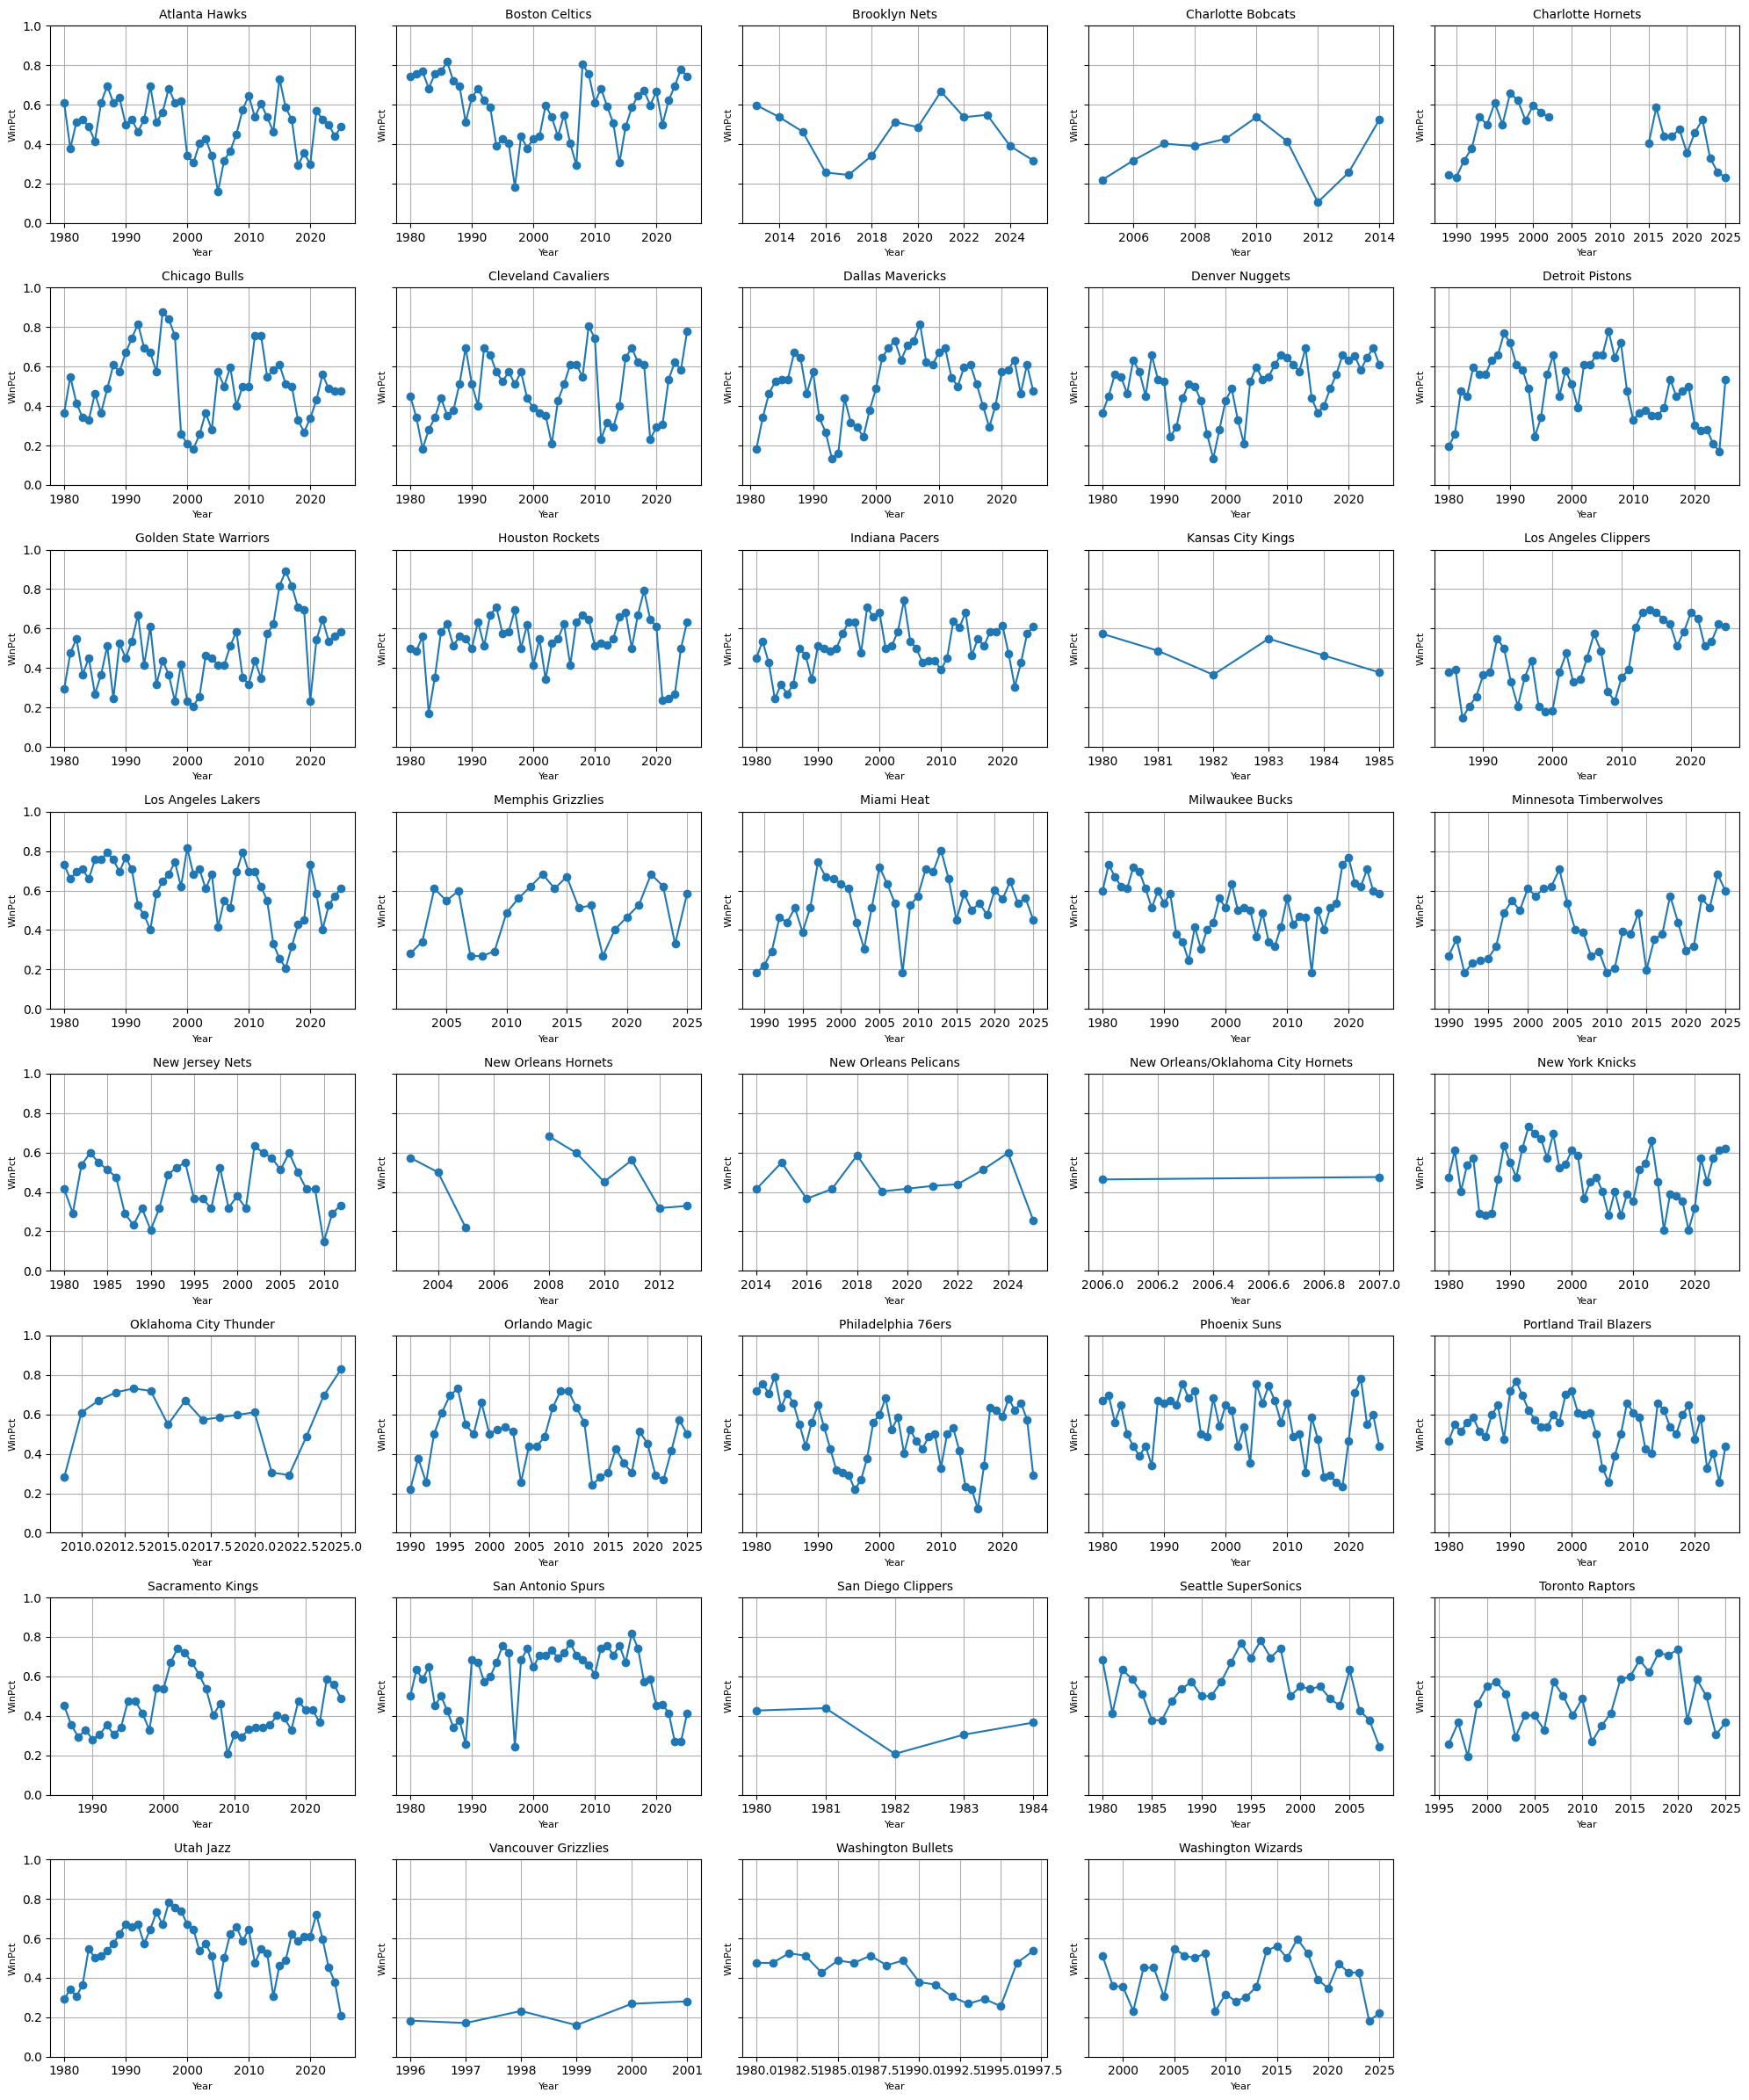

In [ ]:
import matplotlib.pyplot as plt
import math

# Split the 'Overall' column into Wins and Losses
rankings[['Wins', 'Losses']] = rankings['Overall'].str.split('-', expand=True).astype(int)

# Compute win percentage
rankings['WinPct'] = rankings['Wins'] / (rankings['Wins'] + rankings['Losses'])

# Pivot the table to have Teams as columns and Years as index
win_pct_df = rankings.pivot(index='Year', columns='Team', values='WinPct')

teams = win_pct_df.columns
num_teams = len(teams)

# Determine grid size
n_cols = 5
n_rows = math.ceil(num_teams / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3), sharey=True)
axes = axes.flatten()  # flatten in case of multiple rows

for i, team in enumerate(teams):
    axes[i].plot(win_pct_df.index, win_pct_df[team], marker='o')
    axes[i].set_title(team, fontsize=10)
    axes[i].set_xlabel('Year', fontsize=8)
    axes[i].set_ylabel('WinPct', fontsize=8)
    axes[i].set_ylim(0, 1)
    axes[i].grid(True)

# Remove any empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# **Creating team-level dataset**

This code constructs team-level features by aggregating the previous season’s individual statistics of players who appear on a given year’s roster.

For each (Year, Team):

1. It takes the team’s current roster (for example the 1996 roster).

2. For every player on that roster, it retrieves their statistics from the previous season (for example 1995).

3. It sums those individual statistics (Points, Assists, Rebounds, Steals, Blocks, etc.).

4. It produces a single row per team per year representing the roster’s accumulated prior-season production.

Conceptually, this creates a measure of the team’s expected strength entering the season, based on the Previous year performance of the players composing that roster.

In [ ]:
# Clean column names
rosters.columns = rosters.columns.str.strip()
playerData.columns = playerData.columns.str.strip()

# Use previous season stats
rosters["Stat_Year"] = rosters["Year"] - 1

# Merge roster with previous-year stats
merged = rosters.merge(
    playerData[[
        "Year", "Player",
        "PTS", "AST", "TRB", "STL", "BLK",
        "FG", "FGA", "3P", "3PA", "FT", "FTA",
        "TOV", "MP"
    ]],
    left_on=["Stat_Year", "Player"],
    right_on=["Year", "Player"],
    how="left"
)

# Fill missing stats with 0 (rookies / players without previous year)
stat_columns = [
    "PTS", "AST", "TRB", "STL", "BLK",
    "FG", "FGA", "3P", "3PA", "FT", "FTA",
    "TOV", "MP"
]

merged[stat_columns] = merged[stat_columns].fillna(0)

# Aggregate to Team-Level
team = (
    merged
    .groupby(["Year_x", "Team"], as_index=False)
    .agg({
        "PTS": "sum",
        "AST": "sum",
        "TRB": "sum",
        "STL": "sum",
        "BLK": "sum",
        "FG": "sum",
        "FGA": "sum",
        "3P": "sum",
        "3PA": "sum",
        "FT": "sum",
        "FTA": "sum",
        "TOV": "sum",
        "MP": "sum"
    })
)

team = team.rename(columns={"Year_x": "Year"})

# Weighted Efficiency Metrics
# Avoid division by zero
team["FG_pct"] = np.where(team["FGA"] > 0, team["FG"] / team["FGA"], 0)
team["3P_pct"] = np.where(team["3PA"] > 0, team["3P"] / team["3PA"], 0)
team["FT_pct"] = np.where(team["FTA"] > 0, team["FT"] / team["FTA"], 0)

# eFG%
team["eFG_pct"] = np.where(
    team["FGA"] > 0,
    (team["FG"] + 0.5 * team["3P"]) / team["FGA"],
    0
)

# TS%
team["TS_pct"] = np.where(
    (team["FGA"] + 0.44 * team["FTA"]) > 0,
    team["PTS"] / (2 * (team["FGA"] + 0.44 * team["FTA"])),
    0
)

# Advanced Features
# Assist to turnover ratio
team["AST_TOV_ratio"] = np.where(
    team["TOV"] > 0,
    team["AST"] / team["TOV"],
    0
)

# Points per minute (offensive intensity proxy)
team["Points_per_minute"] = np.where(
    team["MP"] > 0,
    team["PTS"] / team["MP"],
    0
)

# Defensive proxy
team["Defensive_proxy"] = team["STL"] + team["BLK"]


# Select Final Columns
final_columns = [
    "Year", "Team",
    "PTS", "AST", "TRB", "STL", "BLK",
    "FG_pct", "3P_pct", "FT_pct",
    "eFG_pct", "TS_pct",
    "AST_TOV_ratio",
    "Points_per_minute",
    "Defensive_proxy"
]

total_team_stats = team[final_columns]

# Remove 1980, because there is no 1979 data to compose 1980 (otherwise it will all be 0)
total_team_stats = total_team_stats[total_team_stats['Year'] != 1980].reset_index(drop=True)

display(total_team_stats.head())

display(total_team_stats.tail())

,Year,Team,PTS,AST,TRB,STL,BLK,FG_pct,3P_pct,FT_pct,eFG_pct,TS_pct,AST_TOV_ratio,Points_per_minute,Defensive_proxy
0,1981,Atlanta Hawks,109.8,24.9,46.9,9.6,7.1,0.469731,0.181818,0.760355,0.470852,0.527519,1.303665,0.439200,16.7
1,1981,Boston Celtics,121.7,27.1,49.9,9.9,4.7,0.497908,0.381818,0.768750,0.508891,0.554796,1.348259,0.479511,14.6
2,1981,Chicago Bulls,135.3,29.8,54.5,9.8,5.2,0.481618,0.225806,0.783290,0.484835,0.538392,1.257384,0.476073,15.0
3,1981,Cleveland Cavaliers,133.7,24.0,59.4,10.4,5.9,0.475524,0.222222,0.776025,0.478147,0.520850,1.212121,0.443744,16.3
4,1981,Dallas Mavericks,94.8,20.5,34.0,7.8,3.3,0.478580,0.260000,0.736585,0.486536,0.522487,1.257669,0.423971,11.1


,Year,Team,PTS,AST,TRB,STL,BLK,FG_pct,3P_pct,FT_pct,eFG_pct,TS_pct,AST_TOV_ratio,Points_per_minute,Defensive_proxy
1287,2026,Sacramento Kings,161.4,37.9,59.9,9.0,5.4,0.482563,0.380252,0.794118,0.555961,0.590068,1.963731,0.497994,14.4
1288,2026,San Antonio Spurs,143.0,30.3,57.5,10.1,8.3,0.471530,0.351293,0.785185,0.544039,0.575314,1.881988,0.488889,18.4
1289,2026,Toronto Raptors,161.5,40.6,60.9,10.6,5.6,0.456472,0.350515,0.758621,0.520818,0.552567,1.942584,0.508822,16.2
1290,2026,Utah Jazz,150.0,31.9,78.7,11.2,8.2,0.449876,0.334552,0.744409,0.525684,0.557737,1.490654,0.443393,19.4
1291,2026,Washington Wizards,144.1,37.7,52.7,9.7,7.7,0.436968,0.335341,0.781931,0.508092,0.547809,1.857143,0.500695,17.4


### **Correlation Matrix**

Here I search for correlations between all the different features in the aggregated team data.

Specifically, I am looking for strong correlations between the feature columns and Win_pct (Win Percentage). A strong correlation may indicate that the feature could be useful for predicting team success in later modeling steps.

Below we can see that the strongest correlations with win percentage are TS_pct (True Shooting Percentage), eFG_pct (Effective Field Goal Percentage), and FG_pct (Field Goal Percentage). These are all shooting efficiency statistics, which suggests that teams that score more efficiently tend to win more games.

I initially expected PTS (Points) to have the strongest correlation with winning, but the results show that efficiency metrics are actually more strongly related to success than raw scoring totals. This suggests that how efficiently a team scores is more important than simply how many points it scores

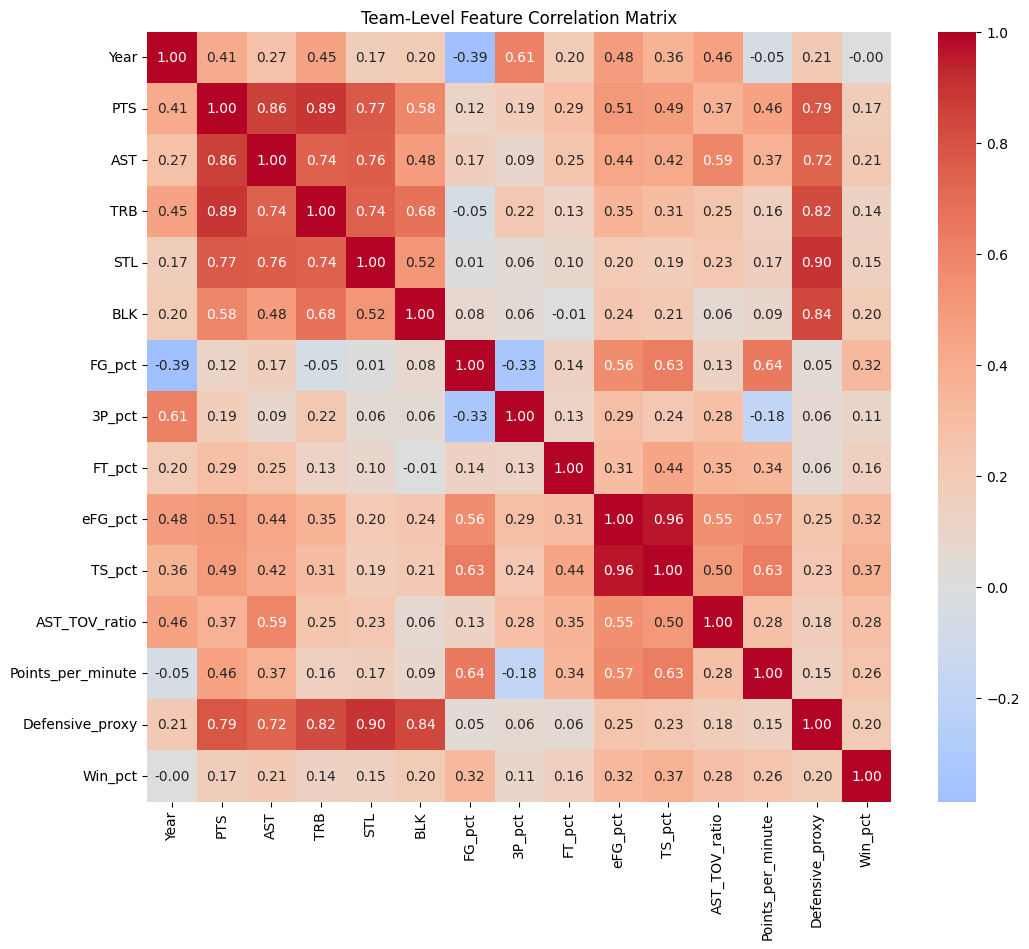

Top features most correlated with Win %:
TS_pct               0.373752
eFG_pct              0.321945
FG_pct               0.319506
AST_TOV_ratio        0.275443
Points_per_minute    0.257676
AST                  0.212889
Defensive_proxy      0.197466
BLK                  0.196094
PTS                  0.174955
FT_pct               0.159364
STL                  0.153971
TRB                  0.139465
3P_pct               0.109994
Year                 0.000983
Name: Win_pct, dtype: float64


/tmp/ipykernel_263/4130839301.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')


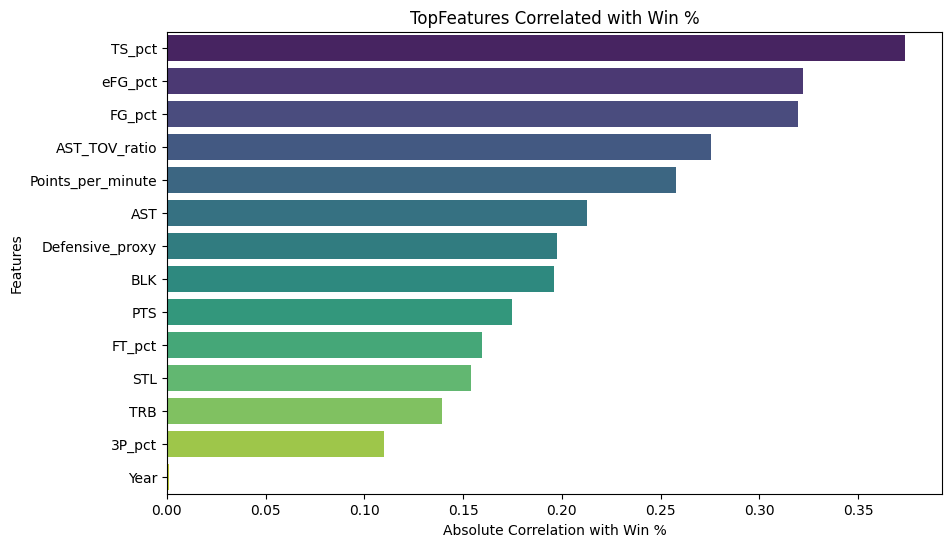

In [45]:
import seaborn as sns

# Prepare team-level data with Win %
rankings[['Wins', 'Losses']] = rankings['Overall'].str.split('-', expand=True).astype(int)
rankings['Win_pct'] = rankings['Wins'] / (rankings['Wins'] + rankings['Losses'])

# Merge with total_team_stats to get team stats per year
team_data = pd.merge(total_team_stats, rankings[['Year', 'Team', 'Win_pct']], on=['Year', 'Team'], how='inner')

# Keep only numeric columns for correlation
numeric_cols = team_data.select_dtypes(include=[np.number]).columns
team_numeric = team_data[numeric_cols]

# Compute correlation matrix
corr_matrix = team_numeric.corr()

# Plot correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Team-Level Feature Correlation Matrix')
plt.show()

# Top features most correlated with Win %
corr_with_win_pct = corr_matrix['Win_pct'].drop('Win_pct')
top_corr = corr_with_win_pct.abs().sort_values(ascending=False).head(20)

print("Top features most correlated with Win %:")
print(top_corr)

# Barplot for top correlated features
plt.figure(figsize=(10,6))
sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')
plt.title('TopFeatures Correlated with Win %')
plt.xlabel('Absolute Correlation with Win %')
plt.ylabel('Features')
plt.show()

## **Splitting into different eras**

Here I decided to look at correlation to win percentage again, but now I'm Splitting it to 3 different eras.

I decided to do it because of the different play styles of the NBA over these years:

**1980–1995 “Early Modern Era”:**

* In this period, NBA play was generally faster-paced, higher-scoring, and focused on transition offense, with less emphasis on three-point shooting compared to later eras.

* Because of this, it makes sense that TS_pct (True Shooting %), eFG_pct (Effective FG %), and FG_pct (Field Goal %) are the top correlates with win percentage—with the fast pace, it was crucial that teams converted possessions efficiently to score points. Points_per_minute also reflects this pace, showing that teams that scored quickly were more likely to win.



**1995–2010 “Post-Jordan Era”:**

* In this period, NBA play was defined by a slower pace, stronger defenses, and isolation-heavy offenses, with more mid-range shots and lower scoring than previous eras.

* Because of this, it makes sense that AST_TOV_ratio, TS_pct, eFG_pct, and FG_pct are the top correlates with win percentage—since possessions were more precious, teams needed to score efficiently and take care of the ball. Points_per_minute and 3P_pct also contributed, reflecting the gradual rise of three-point shooting as a strategic weapon.

* I find it particularly interesting that AST_TOV_ratio has such a high correlation, higher than in previous and succeeding eras, highlighting how critical ball control and efficient passing became in this slower, more methodical style of play.



**2010–2025 “Analytics / Pace-and-Space Era”:**

* In this era, the NBA is defined by fast pace, heavy three-point usage, and spacing-oriented offenses, with efficiency and volume from beyond the arc becoming central to team strategy.

* Because of this, it’s unsurprising that FG_pct, TS_pct, eFG_pct, and 3P_pct are the top correlates with win percentage—efficient shooting, especially from three, drives winning in a high-possession, high-volume style. Points_per_minute also matters, reflecting the importance of scoring quickly in fast-paced games.

* Interestingly, AST_TOV_ratio is less dominant than in the 1995–2010 era, showing that while ball control still helps, shooting efficiency now outweighs pure passing efficiency as the main driver of wins in the modern NBA.


=== Period: 1980-1995 ===


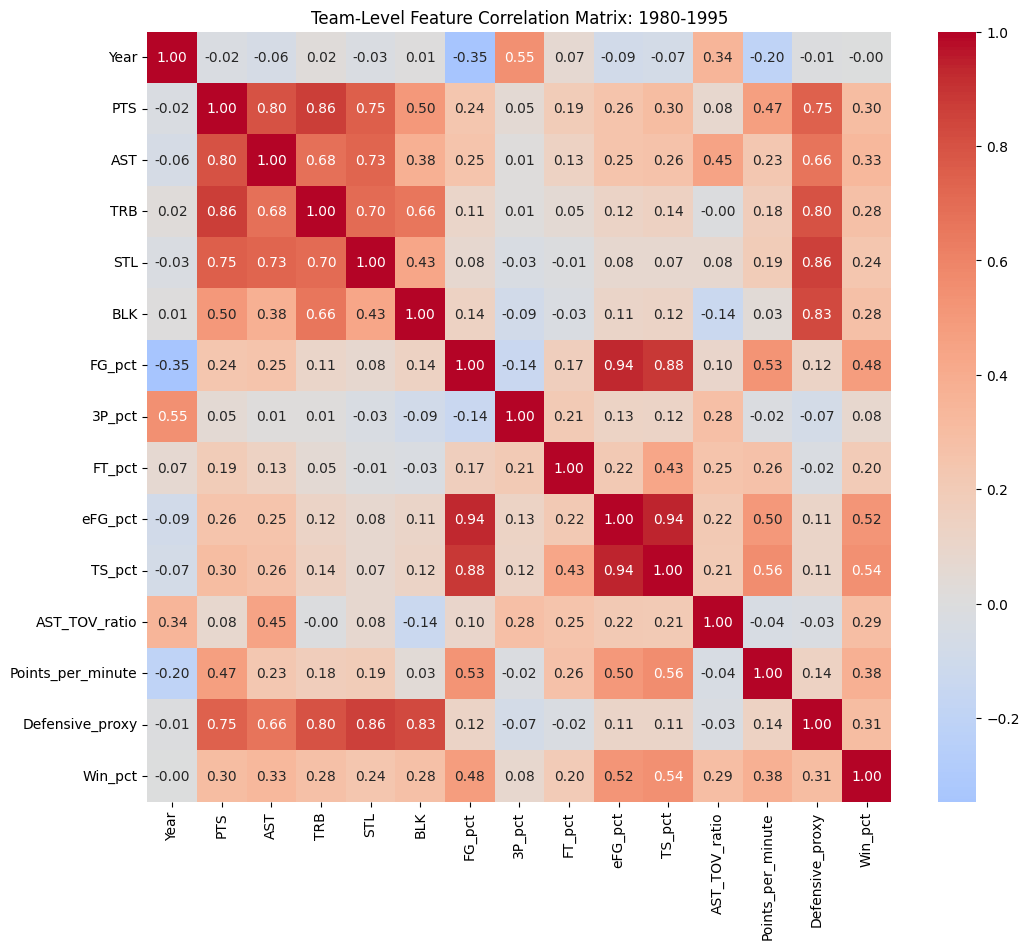

Top 20 features most correlated with Win %:
TS_pct               0.542927
eFG_pct              0.519705
FG_pct               0.482683
Points_per_minute    0.382648
AST                  0.328374
Defensive_proxy      0.305299
PTS                  0.296976
AST_TOV_ratio        0.290733
BLK                  0.278592
TRB                  0.277068
STL                  0.239807
FT_pct               0.195776
3P_pct               0.083935
Year                 0.000000
Name: Win_pct, dtype: float64

=== Period: 1995-2010 ===


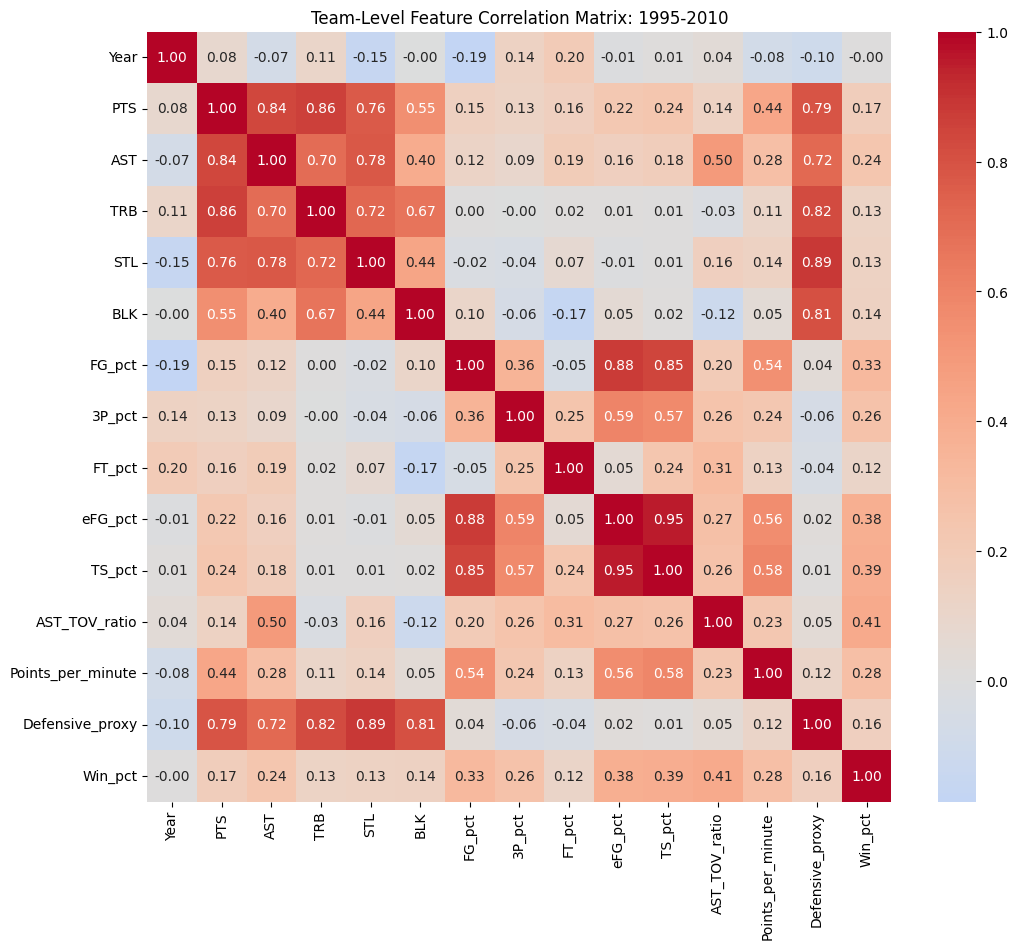

Top 20 features most correlated with Win %:
AST_TOV_ratio        0.411293
TS_pct               0.391119
eFG_pct              0.384157
FG_pct               0.327912
Points_per_minute    0.283570
3P_pct               0.264405
AST                  0.241065
PTS                  0.173231
Defensive_proxy      0.162822
BLK                  0.143658
STL                  0.134680
TRB                  0.128284
FT_pct               0.118491
Year                 0.000000
Name: Win_pct, dtype: float64

=== Period: 2010-2025 ===


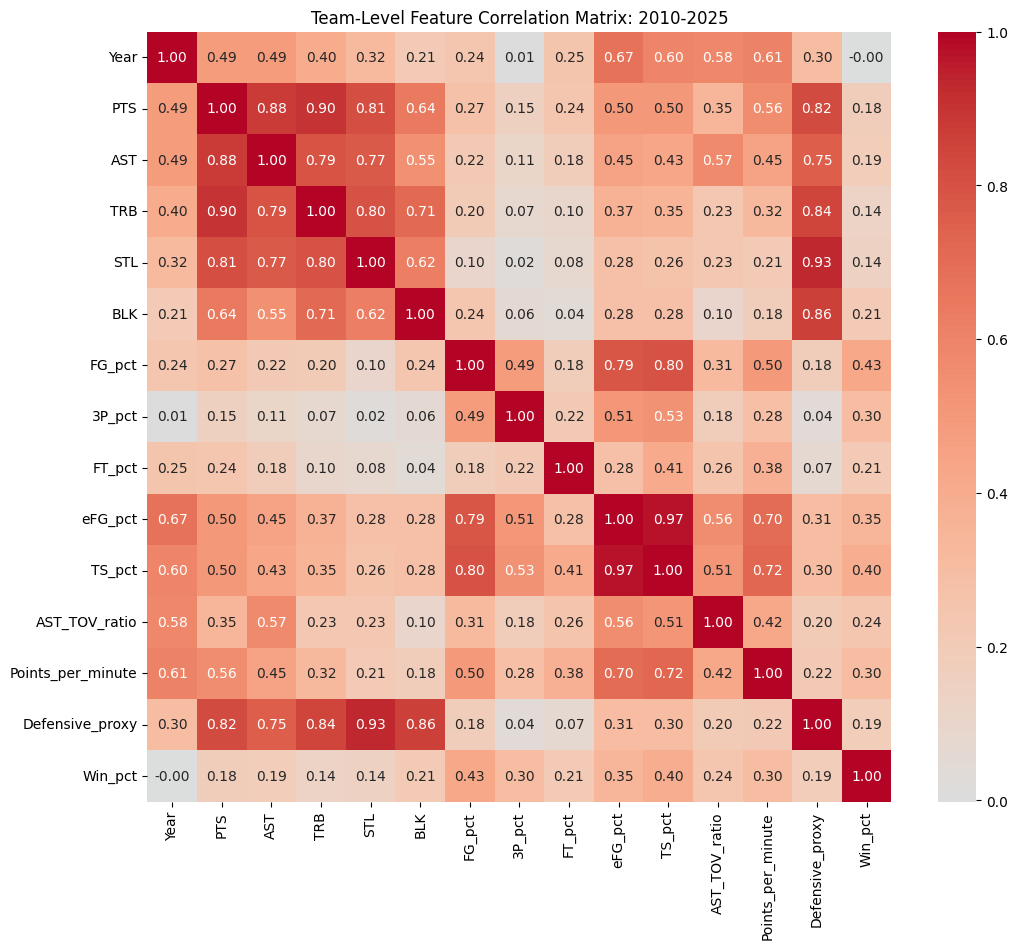

Top 20 features most correlated with Win %:
FG_pct               0.426331
TS_pct               0.397398
eFG_pct              0.345174
3P_pct               0.303140
Points_per_minute    0.302022
AST_TOV_ratio        0.237688
FT_pct               0.211742
BLK                  0.207635
AST                  0.186379
Defensive_proxy      0.185325
PTS                  0.181007
STL                  0.138683
TRB                  0.135074
Year                 0.001588
Name: Win_pct, dtype: float64


In [46]:
# Define periods
periods = [(1980, 1995), (1995, 2010), (2010, 2025)]

# Loop through periods and compute correlation matrices
for start_year, end_year in periods:
    print(f"\n=== Period: {start_year}-{end_year} ===")

    period_data = team_data[(team_data['Year'] >= start_year) & (team_data['Year'] < end_year)]

    # Keep only numeric columns
    numeric_cols = period_data.select_dtypes(include=[np.number]).columns
    period_numeric = period_data[numeric_cols]

    # Correlation matrix
    corr_matrix = period_numeric.corr()

    # Heatmap
    plt.figure(figsize=(12,10))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
    plt.title(f'Team-Level Feature Correlation Matrix: {start_year}-{end_year}')
    plt.show()

    # Top 20 features correlated with Win %
    corr_with_win_pct = corr_matrix['Win_pct'].drop('Win_pct')
    top20_corr = corr_with_win_pct.abs().sort_values(ascending=False).head(20)

    # Format as normal decimal (not scientific)
    top20_corr = top20_corr.apply(lambda x: float(f"{x:.6f}"))

    print("Top 20 features most correlated with Win %:")
    print(top20_corr)

### **Scatter plots**


Here I examine the relationship between individual team statistics and win percentage using scatter plots. Specifically, I’m looking for linear patterns that indicate a strong linear correlation between each feature and win percentage. Such patterns could reveal which features are linearly predictive of team success.

The scatter plot analysis of win percentage versus key team statistics across three eras (1980–1995, 1995–2010, 2010–2015) revealed no clear linear relationships. None of the features, including scoring, assists, rebounds, shooting efficiency, or defensive metrics, showed a consistently strong linear pattern with win percentage. This suggests that team success is influenced by a combination of factors and may involve nonlinear interactions or threshold effects rather than simple linear trends.


=== Scatter Plots Grid: 1980-1995 ===


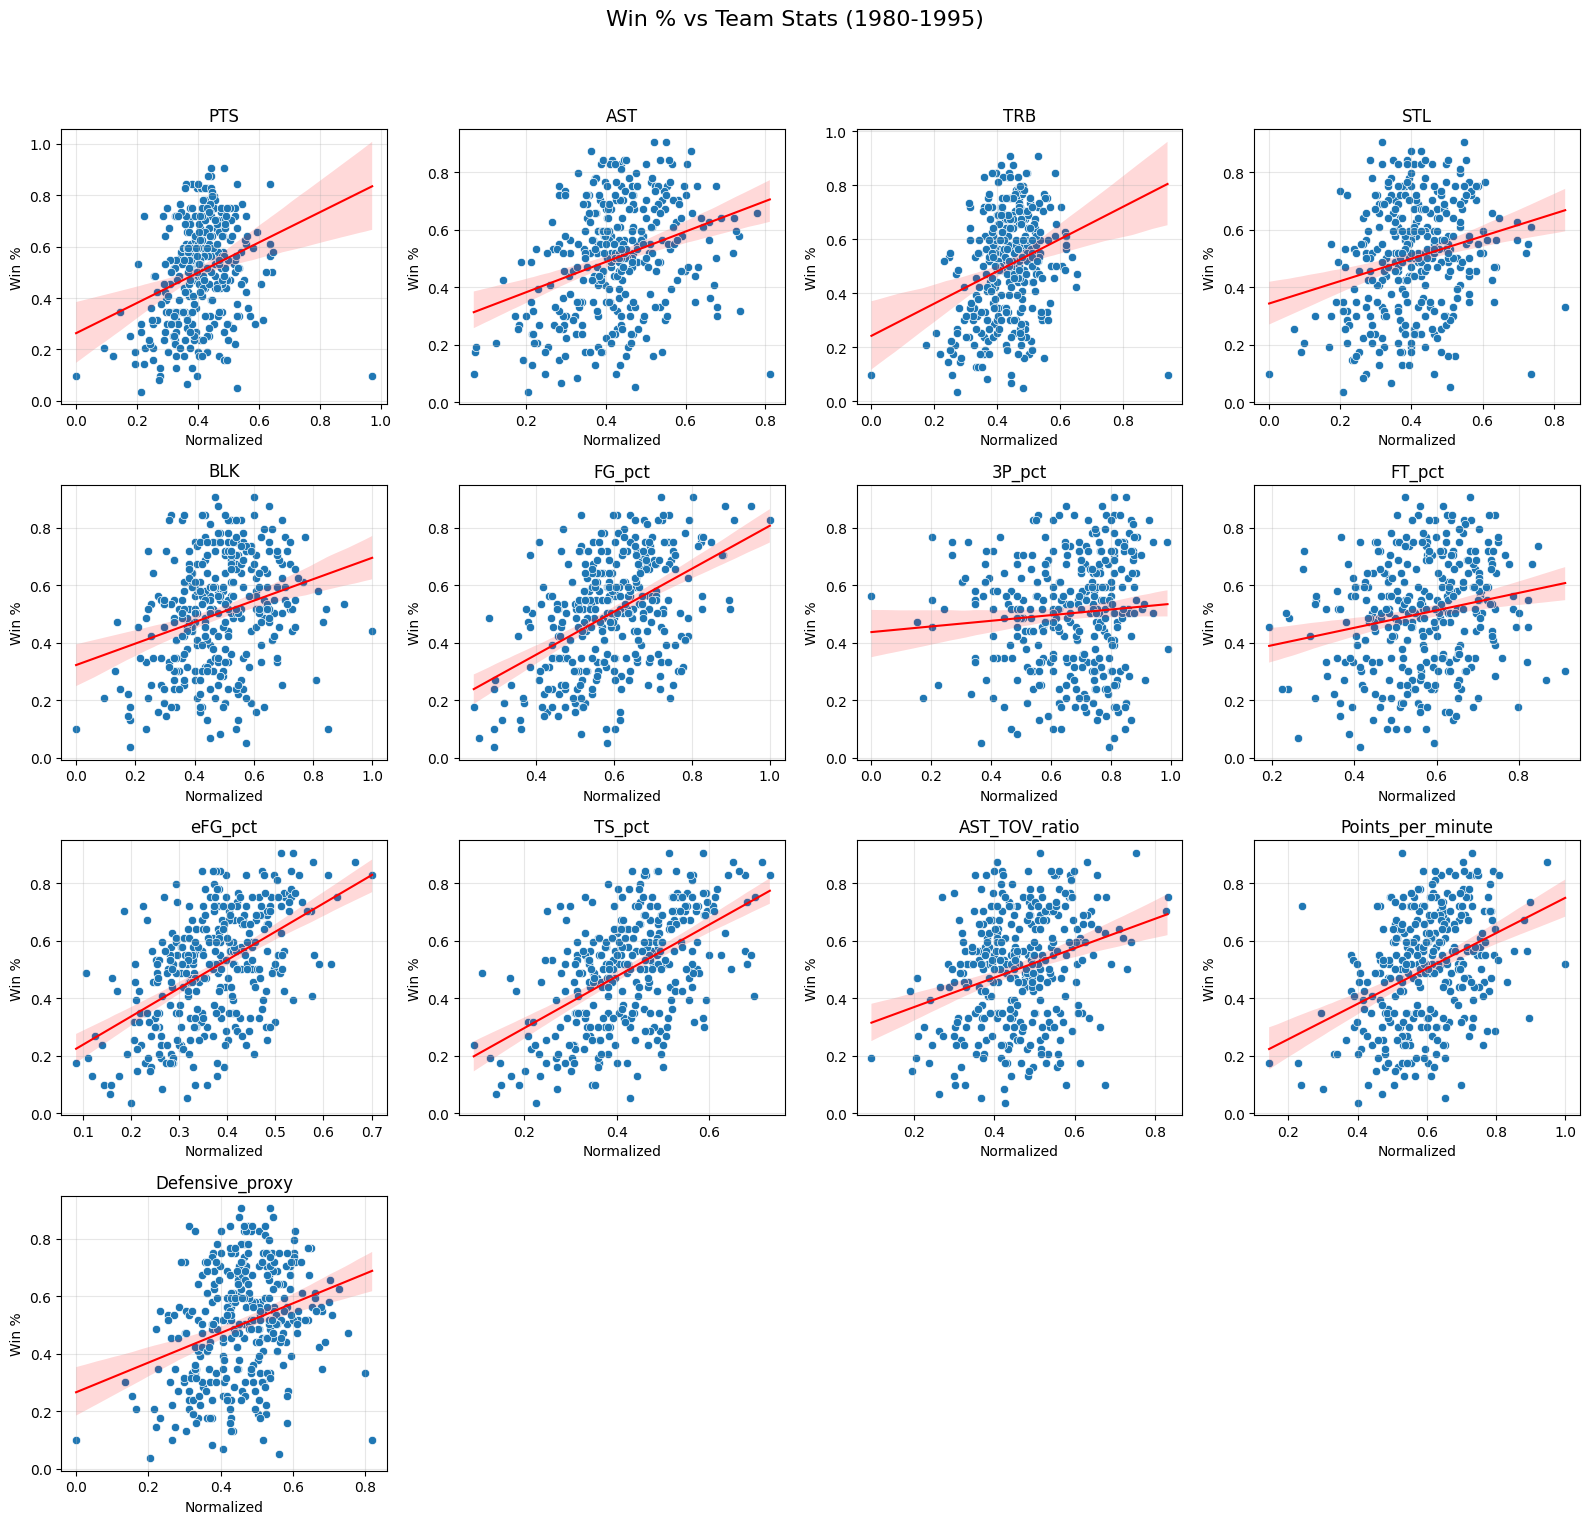


=== Scatter Plots Grid: 1995-2010 ===


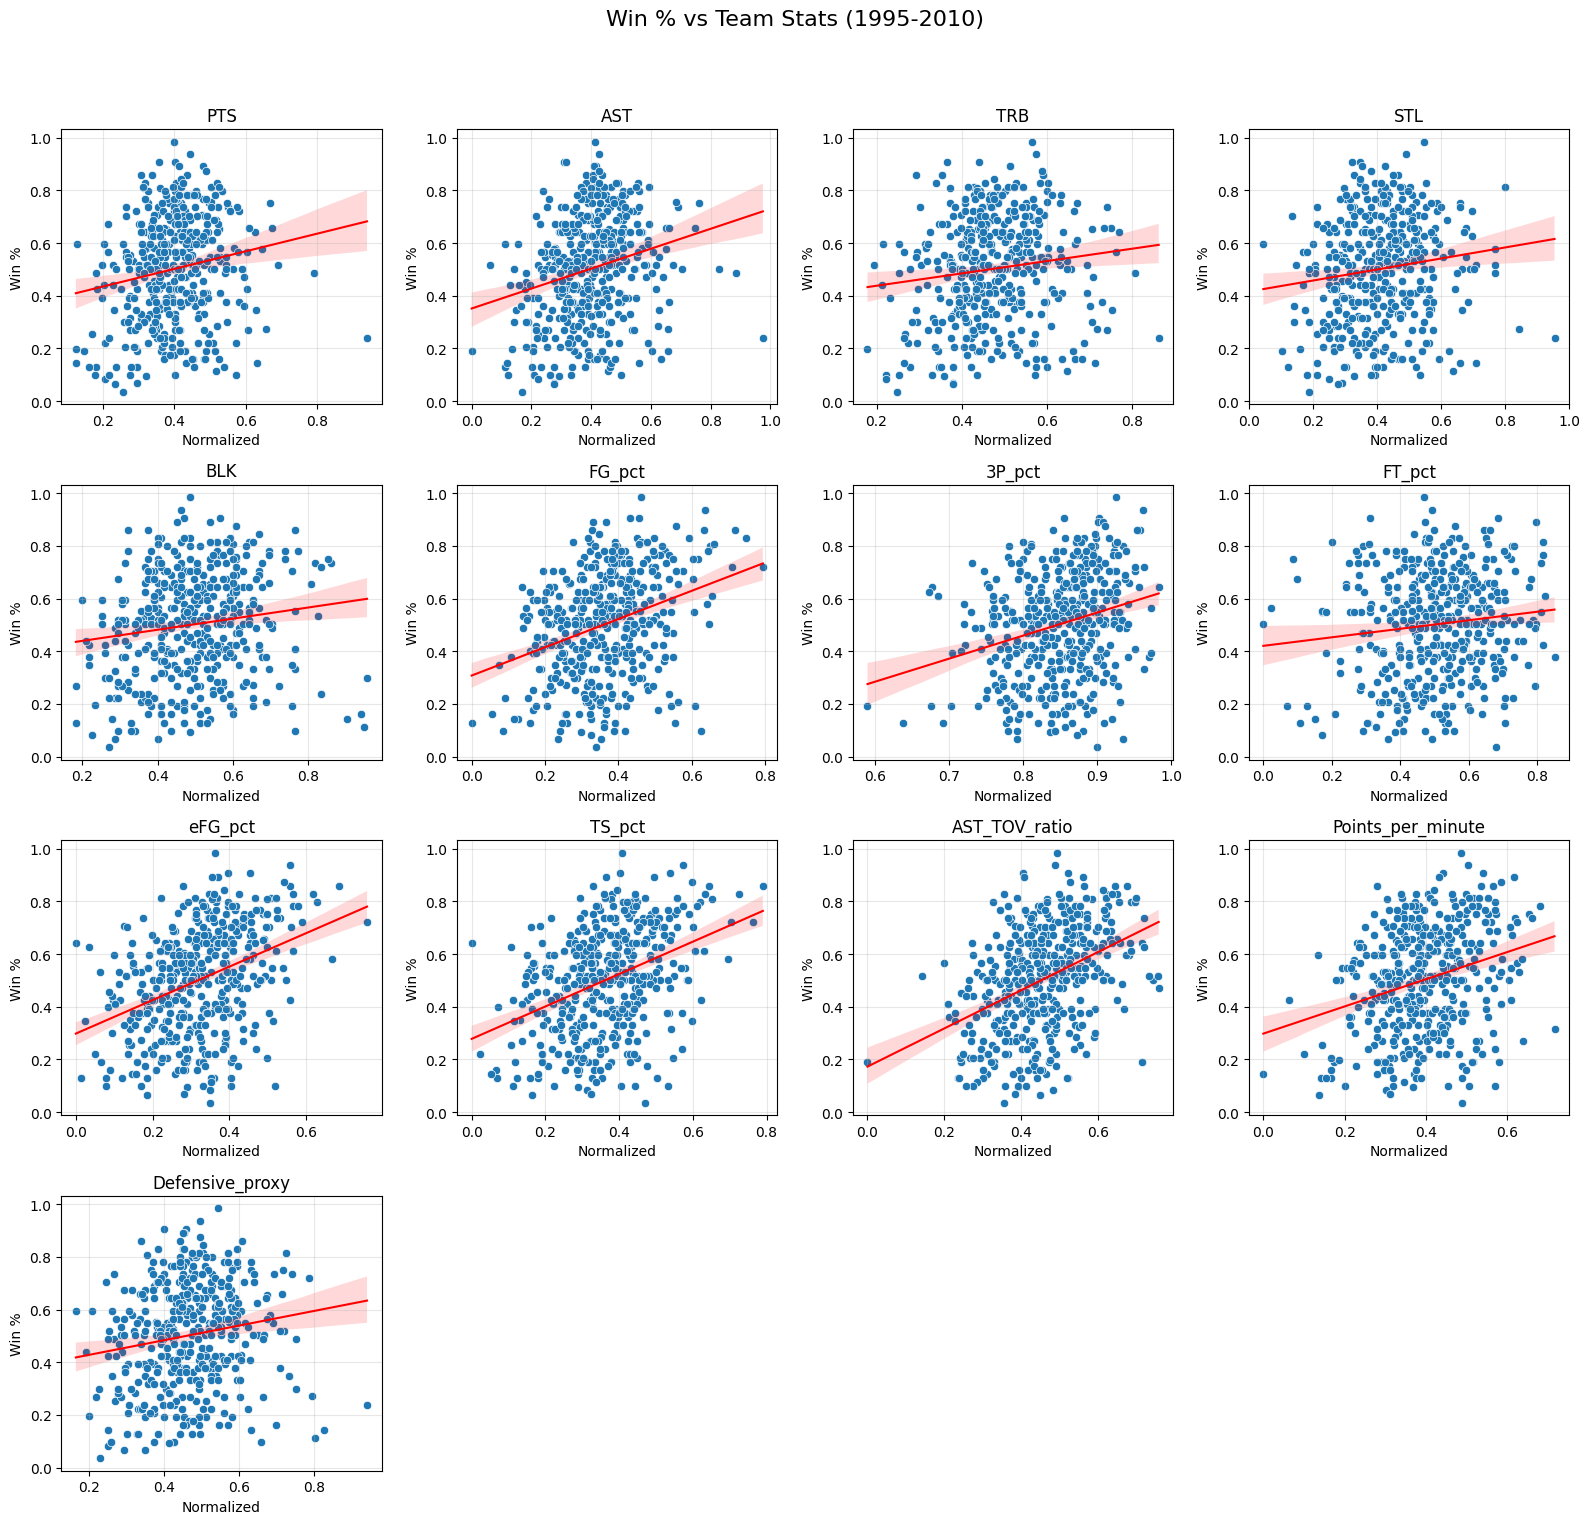


=== Scatter Plots Grid: 2010-2025 ===


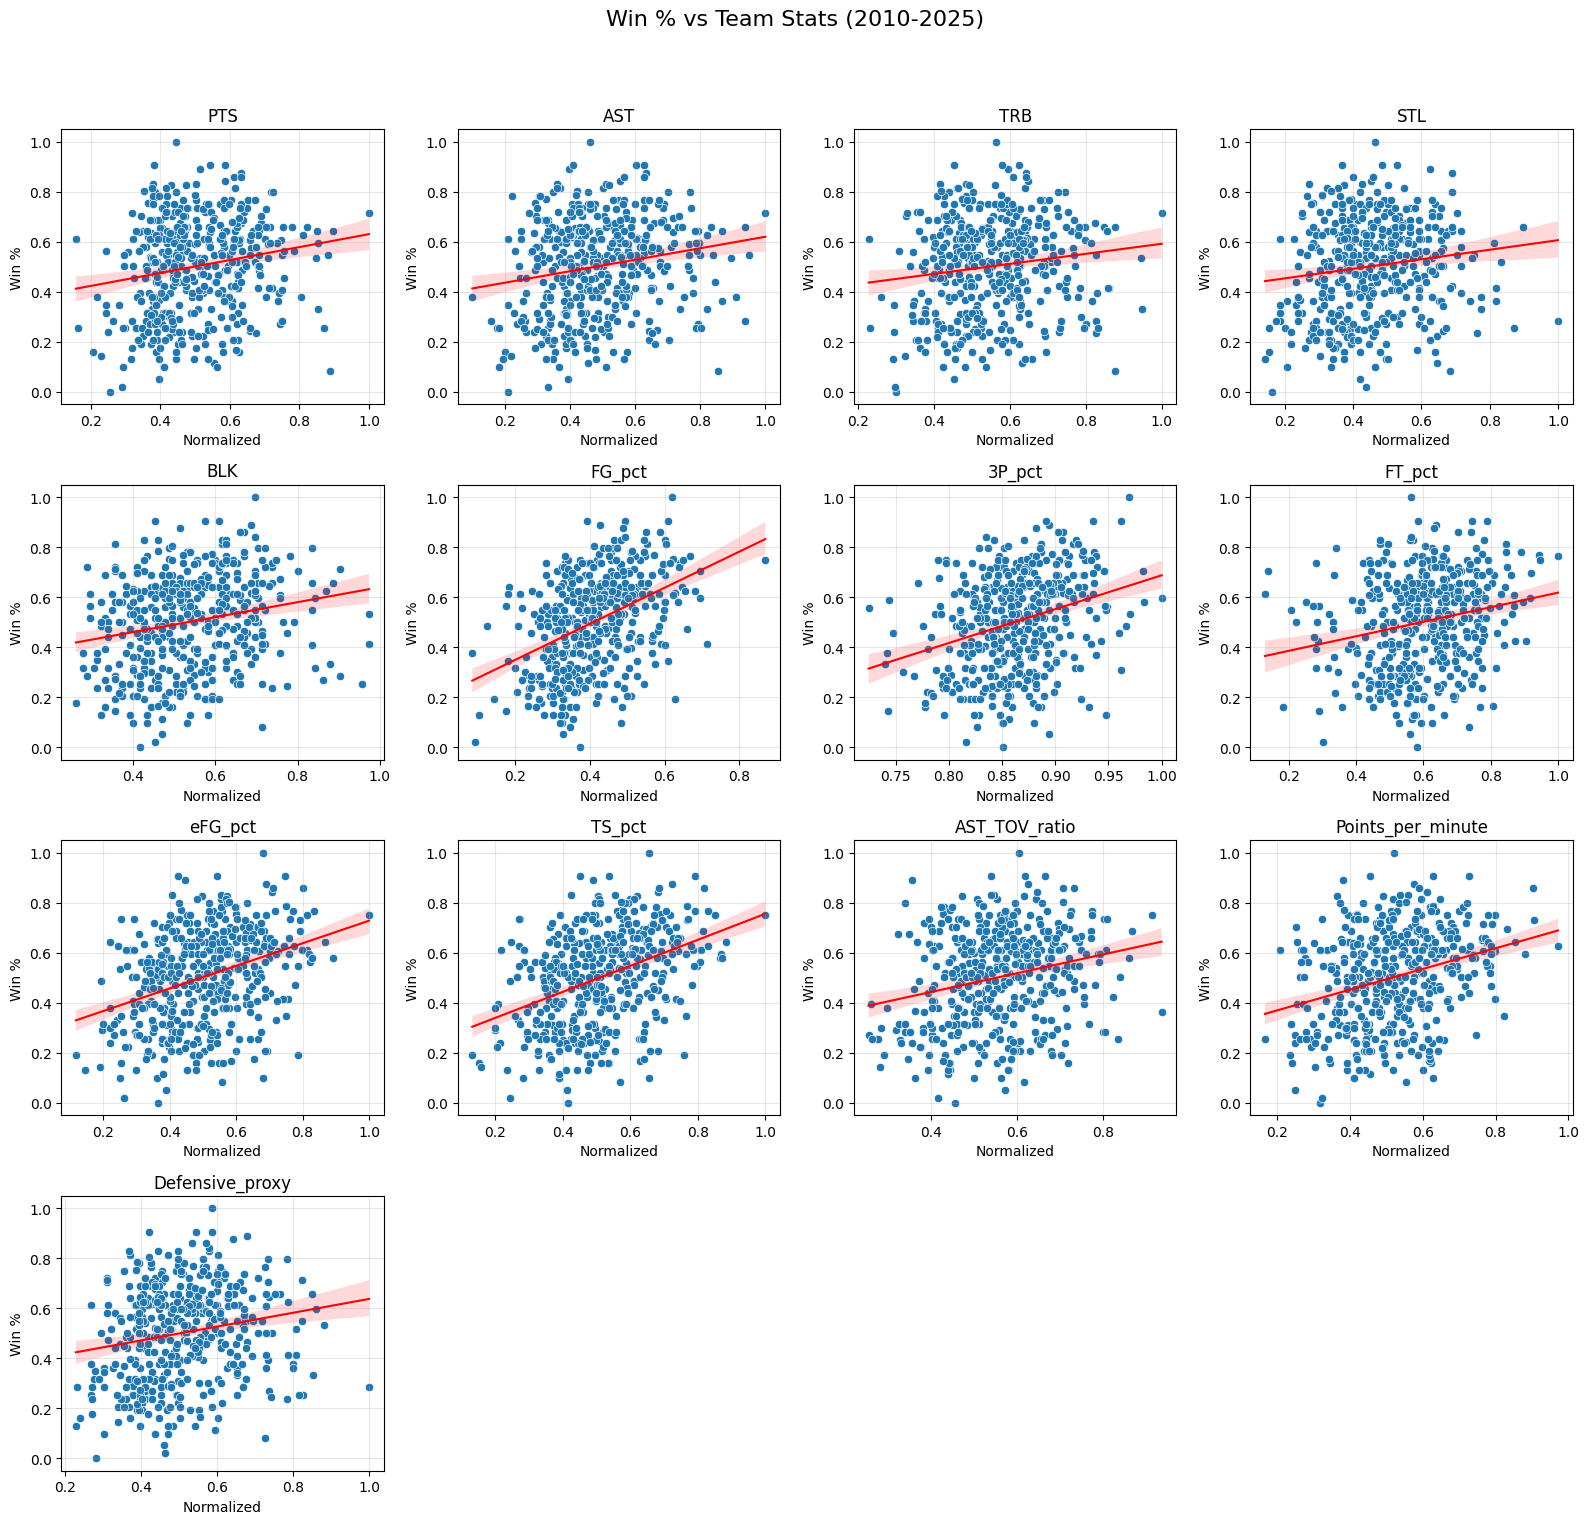

In [47]:
from sklearn.preprocessing import MinMaxScaler

# Key features to plot
features = ['PTS', 'AST', 'TRB', 'STL', 'BLK',
            'FG_pct', '3P_pct', 'FT_pct', 'eFG_pct', 'TS_pct',
            'AST_TOV_ratio', 'Points_per_minute', 'Defensive_proxy']

# Normalize numeric features (0-1)
scaler = MinMaxScaler()
team_data_norm = team_data.copy()
team_data_norm[features + ['Win_pct']] = scaler.fit_transform(team_data_norm[features + ['Win_pct']])

# Plot all features in a grid per era
for start_year, end_year in periods:
    period_data = team_data_norm[(team_data_norm['Year'] >= start_year) & (team_data_norm['Year'] < end_year)]

    print(f"\n=== Scatter Plots Grid: {start_year}-{end_year} ===")

    n_features = len(features)
    n_cols = 4  # adjust number of columns
    n_rows = math.ceil(n_features / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
    axes = axes.flatten()  # flatten to 1D array for easy indexing

    for i, feat in enumerate(features):
        ax = axes[i]
        sns.scatterplot(data=period_data, x=feat, y='Win_pct', ax=ax)
        sns.regplot(data=period_data, x=feat, y='Win_pct', scatter=False, color='red', line_kws={'linewidth':1.5}, ax=ax)
        ax.set_title(f'{feat}')
        ax.set_xlabel('Normalized')
        ax.set_ylabel('Win %')
        ax.grid(True, alpha=0.3)

    # Remove any empty subplots
    for j in range(n_features, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f'Win % vs Team Stats ({start_year}-{end_year})', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

### **Predictive Modeling (1981–2015 Train, 2016–2025 Test)**

Here I trained three regression models — Linear Regression, Ridge Regression, and Random Forest — to predict team win percentage based on roster-aggregated prior-season statistics. The dataset was split chronologically to prevent data leakage: seasons up to 2015 were used for training (962 samples), and seasons after 2015 were used for testing (300 samples). Model performance was evaluated using R², MAE, and RMSE.

The results show that all models struggled to generalize to the modern NBA era. Both Linear Regression and Ridge Regression produced strongly negative R² values (around -1.78), indicating that they performed worse than a simple baseline model predicting the average win percentage. This suggests that the relationship between roster-based features and win percentage is not well captured by a linear structure, especially across different NBA eras.

Random Forest performed substantially better than the linear models, achieving a lower prediction error (MAE ≈ 0.137), but still produced a negative R² (-0.43). This indicates that while nonlinear modeling improves predictive performance, prior-season aggregated player statistics alone are insufficient to accurately predict modern team success.

Feature importance from the Random Forest model shows that True Shooting Percentage (TS_pct) was the strongest predictor, followed by Assist-to-Turnover Ratio and Effective Field Goal Percentage (eFG_pct). This reinforces earlier correlation findings that efficiency and ball control are more predictive of team success than raw scoring totals. Overall, the results suggest that team win percentage depends on complex, nonlinear interactions and contextual factors beyond simple additive roster statistics.

Training samples: 962
Testing samples: 300

Model Comparison:
                         R2       MAE      RMSE
Linear Regression -1.793966  0.204874  0.245063
Ridge             -1.777566  0.204136  0.244343
Random Forest     -0.427747  0.136804  0.175184

Random Forest Feature Importance:
              Feature  Importance
9              TS_pct    0.204088
10      AST_TOV_ratio    0.122654
8             eFG_pct    0.089125
12    Defensive_proxy    0.080667
1                 AST    0.068014
4                 BLK    0.065133
7              FT_pct    0.059580
2                 TRB    0.056715
11  Points_per_minute    0.055680
6              3P_pct    0.054712
0                 PTS    0.054334
5              FG_pct    0.048577
3                 STL    0.040721


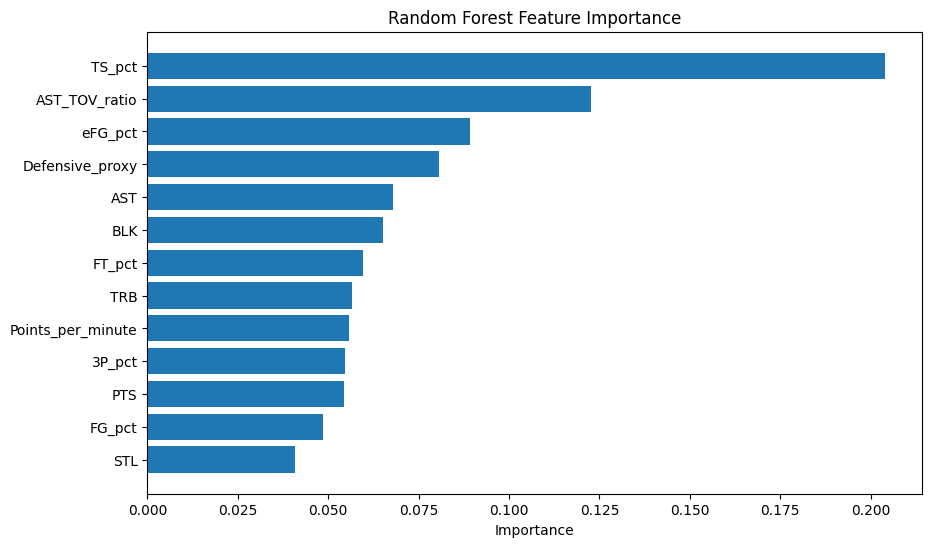

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Prepare Data
# Define feature columns (exclude Year, Team, Win_pct)
feature_cols = [
    'PTS', 'AST', 'TRB', 'STL', 'BLK',
    'FG_pct', '3P_pct', 'FT_pct',
    'eFG_pct', 'TS_pct',
    'AST_TOV_ratio',
    'Points_per_minute',
    'Defensive_proxy'
]

X = team_data[feature_cols]
y = team_data['Win_pct']

# Time-Based Train/Test Split
train_data = team_data[team_data['Year'] <= 2015]
test_data  = team_data[team_data['Year'] > 2015]

X_train = train_data[feature_cols]
y_train = train_data['Win_pct']

X_test = test_data[feature_cols]
y_test = test_data['Win_pct']

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Scale Data (important for Linear/Ridge)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        random_state=42
    )
}

results = {}

for name, model in models.items():

    # Use scaled data for linear models
    if name in ["Linear Regression", "Ridge"]:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    results[name] = {
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    }

# Compare Results
results_df = pd.DataFrame(results).T
print("\nModel Comparison:")
print(results_df)

# Random Forest Feature Importance
rf_model = models["Random Forest"]

importances = rf_model.feature_importances_

feat_importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nRandom Forest Feature Importance:")
print(feat_importance_df)

# Plot feature importance
plt.figure(figsize=(10,6))
plt.barh(feat_importance_df["Feature"], feat_importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

### **Era-Based Predictive Modeling**

Here I trained three regression models — Linear Regression, Ridge, and Random Forest — using era-specific training and testing splits. For each period, I used roster-aggregated team statistics to predict win percentage in the subsequent era. The baseline model simply predicts the mean win percentage of the training set, providing a reference point for performance.

**1980–1990 --> 1990–1995:**
* Linear and Ridge Regression performed well, achieving R² ≈ 0.42, MAE ≈ 0.104, and RMSE ≈ 0.124. Random Forest also performed reasonably (R² ≈ 0.35). These positive R² values indicate that prior-season roster statistics are predictive of team success in this era, and linear models capture most of the signal.

**1995–2005 --> 2005–2010:**
* Performance dropped, with Linear/Ridge R² ≈ 0.19 and Random Forest R² ≈ 0.16. Prediction errors (MAE ≈ 0.108–0.112) are higher than in the earlier era. This suggests that while roster stats still contain signal, NBA style changes and increased parity make prediction harder.

**2010–2020 --> 2020–2025:**
* Linear and Ridge models produced negative R² (≈ -0.38 to -0.39), indicating worse-than-baseline performance. Random Forest performed slightly better (R² ≈ -0.14) but still struggled. This shows that modern NBA outcomes are influenced by more complex, nonlinear, or context-dependent factors beyond additive player stats — for example, analytics-driven roster construction, player roles, injuries, and schedule effects.

**Summary:**

* Linear models work well for early eras but fail for modern NBA.

* Random Forest captures some nonlinear patterns, improving performance slightly, especially in later eras.

* Predictive power decreases over time as NBA strategies and roster dynamics evolve.

* Efficiency metrics (TS_pct, eFG_pct, AST_TOV_ratio) remain important predictors, consistent with earlier correlation and feature importance analyses.

This analysis highlights that era-aware modeling is essential, and modern team success may require richer features or more advanced modeling approaches.

In [49]:
# ============================================
# ERA-BASED TRAIN / TEST EVALUATION
# ============================================

# Choose Feature Set
feature_cols = [
    'PTS', 'AST', 'TRB', 'STL', 'BLK',
    'FG_pct', '3P_pct', 'FT_pct',
    'eFG_pct', 'TS_pct',
    'AST_TOV_ratio',
    'Points_per_minute',
    'Defensive_proxy'
]

# Define Era Splits
era_splits = [
    (1980, 1990, 1990, 1995),
    (1995, 2005, 2005, 2010),
    (2010, 2020, 2020, 2025)
]

# Loop Over Eras
all_results = []

for train_start, train_end, test_start, test_end in era_splits:

    print("\n" + "="*60)
    print(f"TRAIN: {train_start}-{train_end} | TEST: {test_start}-{test_end}")
    print("="*60)

    # Training data
    train_data = team_data[
        (team_data['Year'] >= train_start) &
        (team_data['Year'] < train_end)
    ]

    # Testing data
    test_data = team_data[
        (team_data['Year'] >= test_start) &
        (team_data['Year'] < test_end)
    ]

    X_train = train_data[feature_cols]
    y_train = train_data['Win_pct']

    X_test = test_data[feature_cols]
    y_test = test_data['Win_pct']

    print("Training samples:", len(X_train))
    print("Testing samples:", len(X_test))

    # Baseline (predict mean of training set)
    baseline_pred = np.full_like(y_test, y_train.mean())

    baseline_r2 = r2_score(y_test, baseline_pred)
    baseline_mae = mean_absolute_error(y_test, baseline_pred)
    baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

    print("\nBaseline Performance:")
    print("R2:", baseline_r2)
    print("MAE:", baseline_mae)
    print("RMSE:", baseline_rmse)

    # Scale for linear models
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Models
    models = {
        "Linear Regression": LinearRegression(),
        "Ridge": Ridge(alpha=1.0),
        "Random Forest": RandomForestRegressor(
            n_estimators=300,
            random_state=42
        )
    }

    for name, model in models.items():

        if name in ["Linear Regression", "Ridge"]:
            model.fit(X_train_scaled, y_train)
            preds = model.predict(X_test_scaled)
        else:
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

        r2 = r2_score(y_test, preds)
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))

        print(f"\n{name} Performance:")
        print("R2:", r2)
        print("MAE:", mae)
        print("RMSE:", rmse)

        all_results.append({
            "Train Period": f"{train_start}-{train_end}",
            "Test Period": f"{test_start}-{test_end}",
            "Model": name,
            "R2": r2,
            "MAE": mae,
            "RMSE": rmse
        })

# Summary Table
results_df = pd.DataFrame(all_results)

print("\n\nFINAL SUMMARY TABLE")
print("="*60)
print(results_df)


TRAIN: 1980-1990 | TEST: 1990-1995
Training samples: 209
Testing samples: 135

Baseline Performance:
R2: 0.0
MAE: 0.13568202348690153
RMSE: 0.16256097052718457

Linear Regression Performance:
R2: 0.4184208750770366
MAE: 0.10357642237494886
RMSE: 0.1239711666673434

Ridge Performance:
R2: 0.41768605796027813
MAE: 0.1037179237993244
RMSE: 0.12404945986498299

Random Forest Performance:
R2: 0.3508414230263278
MAE: 0.11096085516410727
RMSE: 0.13097598801731727

TRAIN: 1995-2005 | TEST: 2005-2010
Training samples: 288
Testing samples: 150

Baseline Performance:
R2: 0.0
MAE: 0.12357723577235774
RMSE: 0.15107519995697

Linear Regression Performance:
R2: 0.19475303318698411
MAE: 0.10818948206924996
RMSE: 0.13556816777641073

Ridge Performance:
R2: 0.19595435494549485
MAE: 0.10812031850130249
RMSE: 0.13546700516200125

Random Forest Performance:
R2: 0.1571798100388071
MAE: 0.11207260704607042
RMSE: 0.13869494832246482

TRAIN: 2010-2020 | TEST: 2020-2025
Training samples: 300
Testing samples: 1

### **Era-Specific Feature Modeling**

Here I trained three regression models (Linear Regression, Ridge, Random Forest) using only the top correlated features to win percentageidentified earlier for each era:

* 1980–1995: TS_pct, eFG_pct, FG_pct

* 1995–2010: AST_TOV_ratio, TS_pct, eFG_pct

* 2010–2025: FG_pct, TS_pct, eFG_pct

Each era used a chronological train/test split (e.g., 1980–1990 train --> 1990–1995 test). The baseline model predicts the mean win percentage of the training set, providing a reference.

**1980–1990 --> 1990–1995:**
* Linear and Ridge Regression performed well (R² ≈ 0.347, MAE ≈ 0.111, RMSE ≈ 0.131), showing that efficiency metrics captured a substantial portion of team success in this era. Random Forest was slightly worse (R² ≈ 0.197), suggesting nonlinear interactions were less critical here.

**1995–2005 --> 2005–2010:**
* Predictive power dropped. Linear/Ridge R² ≈ 0.134, MAE ≈ 0.113, RMSE ≈ 0.141; Random Forest barely improved over baseline (R² ≈ 0.024). This indicates that while top features still contain some signal, team success became more dependent on context or combinations of stats beyond these three features.

**2010–2020 --> 2020–2025:**
* Linear/Ridge models performed worse than baseline (R² ≈ -0.16 to -0.17), and Random Forest also struggled (R² ≈ -0.34). This shows that even efficiency-focused top features alone are insufficient to predict modern NBA outcomes. The modern era likely requires richer features (roster depth, roles, injuries, lineup synergies) and more complex modeling.

**Summary:**

* Using era-specific top features improves early-era prediction but fails for modern NBA.

* Efficiency metrics (TS_pct, eFG_pct, FG_pct, AST_TOV_ratio) are strong predictors historically but less predictive today.

* Linear models suffice for early eras, but modern outcomes show nonlinear, context-dependent effects that simple aggregated stats cannot capture.

This reinforces the idea that NBA team success is highly era-dependent and increasingly complex, with modern prediction requiring more advanced features and modeling approaches.

In [50]:
# ============================================
# ERA-SPECIFIC FEATURE MODELING
# ============================================

# Define Era Splits + Top Features
era_configs = [
    {
        "train": (1980, 1990),
        "test": (1990, 1995),
        "features": ['TS_pct', 'eFG_pct', 'FG_pct']
    },
    {
        "train": (1995, 2005),
        "test": (2005, 2010),
        "features": ['AST_TOV_ratio', 'TS_pct', 'eFG_pct']
    },
    {
        "train": (2010, 2020),
        "test": (2020, 2025),
        "features": ['FG_pct', 'TS_pct', 'eFG_pct']
    }
]

all_results = []

# Loop Through Eras
for config in era_configs:

    train_start, train_end = config["train"]
    test_start, test_end = config["test"]
    feature_cols = config["features"]

    print("\n" + "="*60)
    print(f"TRAIN: {train_start}-{train_end} | TEST: {test_start}-{test_end}")
    print("Features:", feature_cols)
    print("="*60)

    # Training data
    train_data = team_data[
        (team_data['Year'] >= train_start) &
        (team_data['Year'] < train_end)
    ]

    # Testing data
    test_data = team_data[
        (team_data['Year'] >= test_start) &
        (team_data['Year'] < test_end)
    ]

    X_train = train_data[feature_cols]
    y_train = train_data['Win_pct']

    X_test = test_data[feature_cols]
    y_test = test_data['Win_pct']

    print("Training samples:", len(X_train))
    print("Testing samples:", len(X_test))

    # Baseline Model
    baseline_pred = np.full_like(y_test, y_train.mean())

    baseline_r2 = r2_score(y_test, baseline_pred)
    baseline_mae = mean_absolute_error(y_test, baseline_pred)
    baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

    print("\nBaseline Performance:")
    print("R2:", baseline_r2)
    print("MAE:", baseline_mae)
    print("RMSE:", baseline_rmse)

    # Scale for Linear Models
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define Models
    models = {
        "Linear Regression": LinearRegression(),
        "Ridge": Ridge(alpha=1.0),
        "Random Forest": RandomForestRegressor(
            n_estimators=300,
            random_state=42
        )
    }

    for name, model in models.items():

        if name in ["Linear Regression", "Ridge"]:
            model.fit(X_train_scaled, y_train)
            preds = model.predict(X_test_scaled)
        else:
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

        r2 = r2_score(y_test, preds)
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))

        print(f"\n{name} Performance:")
        print("R2:", r2)
        print("MAE:", mae)
        print("RMSE:", rmse)

        all_results.append({
            "Train Period": f"{train_start}-{train_end}",
            "Test Period": f"{test_start}-{test_end}",
            "Features Used": ", ".join(feature_cols),
            "Model": name,
            "R2": r2,
            "MAE": mae,
            "RMSE": rmse
        })

# Summary Table
results_df = pd.DataFrame(all_results)

print("\n\nFINAL SUMMARY TABLE")
print("="*60)
print(results_df)


TRAIN: 1980-1990 | TEST: 1990-1995
Features: ['TS_pct', 'eFG_pct', 'FG_pct']
Training samples: 209
Testing samples: 135

Baseline Performance:
R2: 0.0
MAE: 0.13568202348690153
RMSE: 0.16256097052718457

Linear Regression Performance:
R2: 0.34756309160162646
MAE: 0.11142302216885033
RMSE: 0.13130629402279734

Ridge Performance:
R2: 0.3470971326359884
MAE: 0.11148092662816139
RMSE: 0.13135317397704202

Random Forest Performance:
R2: 0.19667120828933105
MAE: 0.12046582354712433
RMSE: 0.1457011399779931

TRAIN: 1995-2005 | TEST: 2005-2010
Features: ['AST_TOV_ratio', 'TS_pct', 'eFG_pct']
Training samples: 288
Testing samples: 150

Baseline Performance:
R2: 0.0
MAE: 0.12357723577235774
RMSE: 0.15107519995697

Linear Regression Performance:
R2: 0.13380173534034978
MAE: 0.11258570873123418
RMSE: 0.14060534566188562

Ridge Performance:
R2: 0.13410869724305952
MAE: 0.11258710137984833
RMSE: 0.14058042970981122

Random Forest Performance:
R2: 0.023925761590887662
MAE: 0.12160891056910562
RMSE: 0